# **ML Terapan - Submission Akhir Membuat Model Sistem Rekomendasi**
- **Nama:** Lutfi Aundrie Hermawan
- **Email:** lutfiaunher@gmail.com
- **ID Dicoding:** A126YBF254


## **Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, precision_score, recall_score, f1_score
from sklearn.metrics import mean_squared_error

## Data Preparation

Download Dataset USA Housing Dataset melalui Google Drive

[Google Drive](https://drive.google.com/file/d/1dMlIICJcmkKTsHVDFm263z6GTxtuvWek/view?usp=drive_link)

[Kaggle](https://www.kaggle.com/datasets/shivamb/amazon-prime-movies-and-tv-shows)

## **Mount to Drive**

Menghubungkan penyimpanan Google Drive ke Colab dan mengakses file yang disimpan di Google Drive langsung dari notebook.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Read Dataset**

Memuat data dari csv ke dataframe

In [3]:
df= pd.read_csv('/content/drive/MyDrive/Submission/Submission_One_ML_Terapan/amazon_prime_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama",A small fishing village must procure a local d...
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,NaN,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,NaN,69 min,Documentary,"Pink breaks the mold once again, bringing her ..."
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,NaN,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...


## Data Understanding

###**1. Dataset Information**

Melihat informasi dari dataframe. Dari informasi tersebut bahwa dataset memiliki jumlah data sebanyak 12 kolom dan 9668 baris

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       9668 non-null   object
 1   type          9668 non-null   object
 2   title         9668 non-null   object
 3   director      7585 non-null   object
 4   cast          8435 non-null   object
 5   country       672 non-null    object
 6   date_added    155 non-null    object
 7   release_year  9668 non-null   int64 
 8   rating        9331 non-null   object
 9   duration      9668 non-null   object
 10  listed_in     9668 non-null   object
 11  description   9668 non-null   object
dtypes: int64(1), object(11)
memory usage: 906.5+ KB


###**2. Check Missing Values**

Memeriksa nilai yang hilang (missing values) dalam dataset. Dari dataset ini bahwa missing values berjumlah 5 dimana presentasi missing values besar

In [5]:
print("\nMissing values dalam dataset:")
print(df.isnull().sum())


Missing values dalam dataset:
show_id            0
type               0
title              0
director        2083
cast            1233
country         8996
date_added      9513
release_year       0
rating           337
duration           0
listed_in          0
description        0
dtype: int64


In [6]:
missing_num = df[df.columns].isna().sum().sort_values(ascending=False)
missing_perc = (df[df.columns].isna().sum()/len(df)*100).sort_values(ascending=False)
missing = pd.concat([missing_num,missing_perc],keys=['Total','Percentage'],axis=1)
missing_train = missing[missing['Percentage']>0]
missing_train

,Total,Percentage
date_added,9513,98.396773
country,8996,93.049235
director,2083,21.545304
cast,1233,12.753413
rating,337,3.485726


Berdasarkan data pada dataset, terdapat nilai hilang (missing value) yang cukup tinggi pada kolom date_added dan country, yaitu dengan persentase di atas 90%. Oleh karena itu, solusi yang diambil adalah menghapus kolom tersebut karena jumlah data yang hilang terlalu banyak. Sementara itu, kolom director dan cast dapat diisi dengan nilai 'Other', dan kolom rating dapat diisi dengan ranting rata-rata."

## **Exploratory Data Analysis**

###**1. Tahun Rilis Terbanyak**

Visualisasi distribusi tahun rilis untuk Movie dan TV Show menunjukkan bahwa penambahan konten baru mengalami peningkatan signifikan pada rentang tahun 2015 hingga 2020. Pada periode ini, jumlah konten yang dirilis merupakan yang terbanyak dibandingkan tahun-tahun sebelumnya.

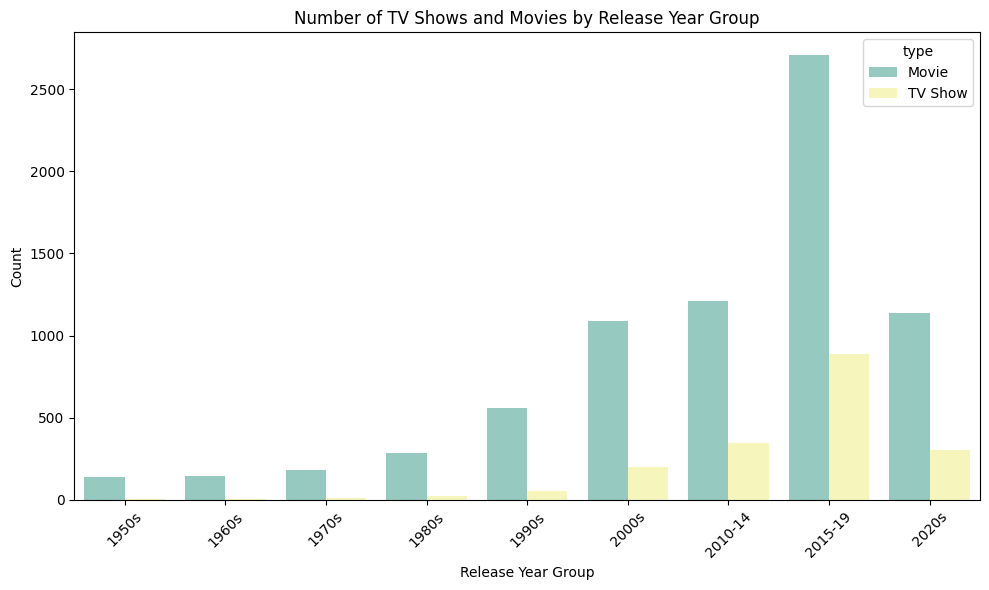

In [7]:
# Pastikan kolom 'release_year' dalam format numerik
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')

# Buat grup tahun (opsional, untuk mengurangi noise jika tahun sangat banyak)
bins = [1950, 1960, 1970, 1980, 1990, 2000, 2010, 2015, 2020, 2025]
labels = ['1950s', '1960s', '1970s', '1980s', '1990s', '2000s', '2010-14', '2015-19', '2020s']
df['year_group'] = pd.cut(df['release_year'], bins=bins, labels=labels)

# Plot menggunakan seaborn
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='year_group', hue='type', palette='Set3')
plt.title('Number of TV Shows and Movies by Release Year Group')
plt.xlabel('Release Year Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###**2. Distribusi Rating Konten**

Distribusi konten berdasarkan rating menunjukkan bahwa Amazon Prime memiliki banyak konten yang ditujukan untuk audiens remaja. Hal ini terlihat dari dominasi kategori rating seperti "13+" dan "16+", yang merupakan dua kategori dengan jumlah konten terbanyak di platform tersebut.

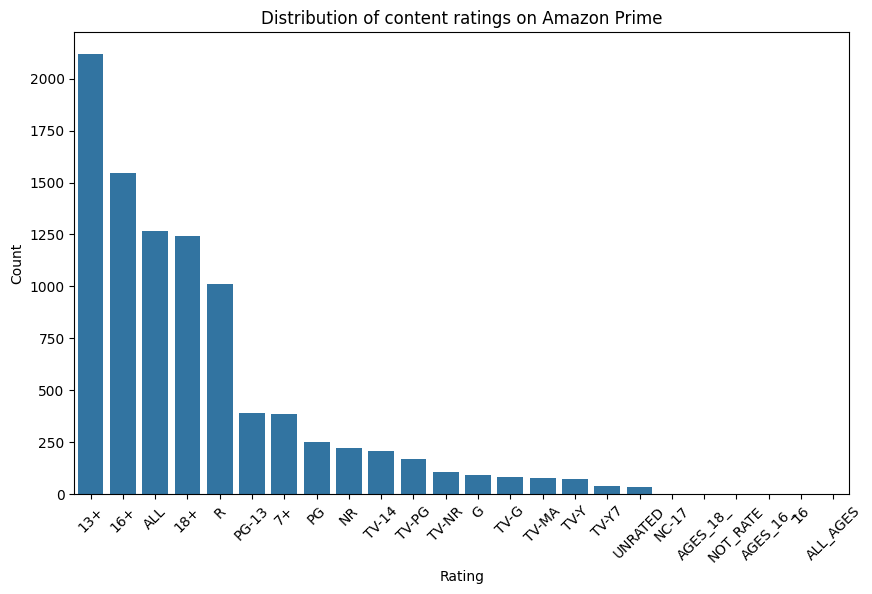

In [8]:
plt.figure(figsize=(10, 6))
sns.countplot(x='rating', order = df['rating'].value_counts().index, data = df)
plt.title('Distribution of content ratings on Amazon Prime')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.show()

### **3. Top Genre Amazon Prime**

Menvisualisasi genre top 5 di Amazon Prime. Visualisasi menunjukkan bahwa genre yang paling banyak ditampilkan dalam dataset adalah Drama, Comedy, Action, Suspense, dan Kids. Kelima genre ini merupakan genre terpopuler dengan jumlah konten terbanyak.

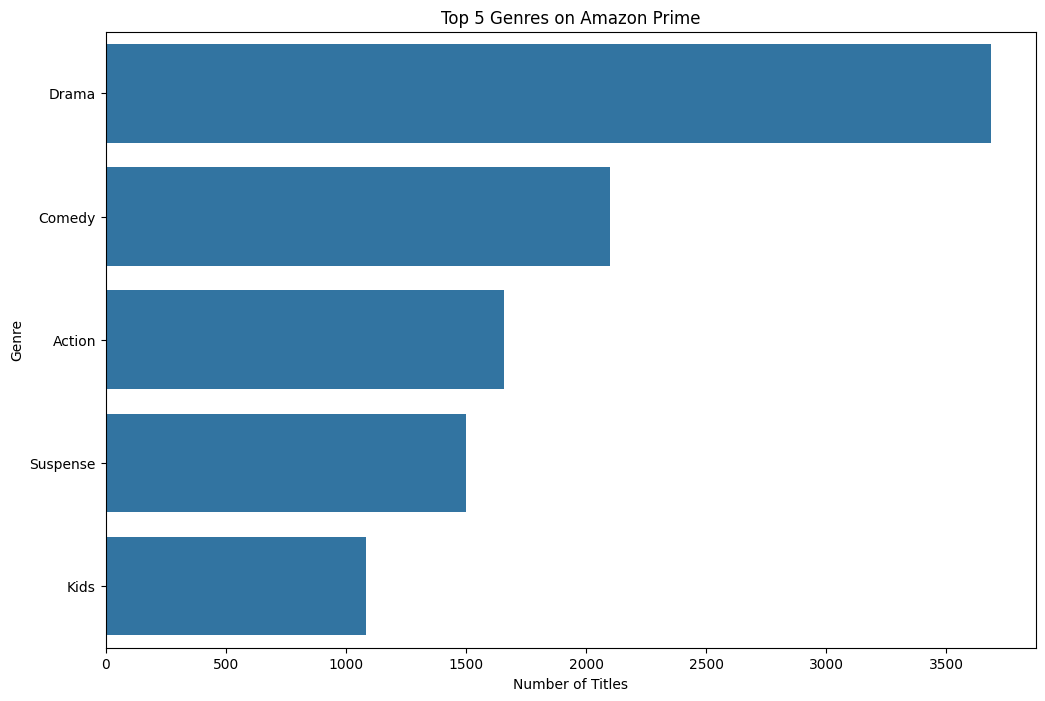

In [9]:
genres = df['listed_in'].str.split(', ', expand=True).stack().value_counts()
plt.figure(figsize=(12, 8))
sns.barplot(x=genres.values[:5], y=genres.index[:5])
plt.title('Top 5 Genres on Amazon Prime')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

###**4. Distribusi Durasi Movie**

Visualisasi menunjukkan distribusi durasi film di Amazon Prime, dengan mayoritas Movie memiliki durasi antara 80 hingga 120 menit. Hal ini mencerminkan preferensi umum terhadap film berdurasi standar.

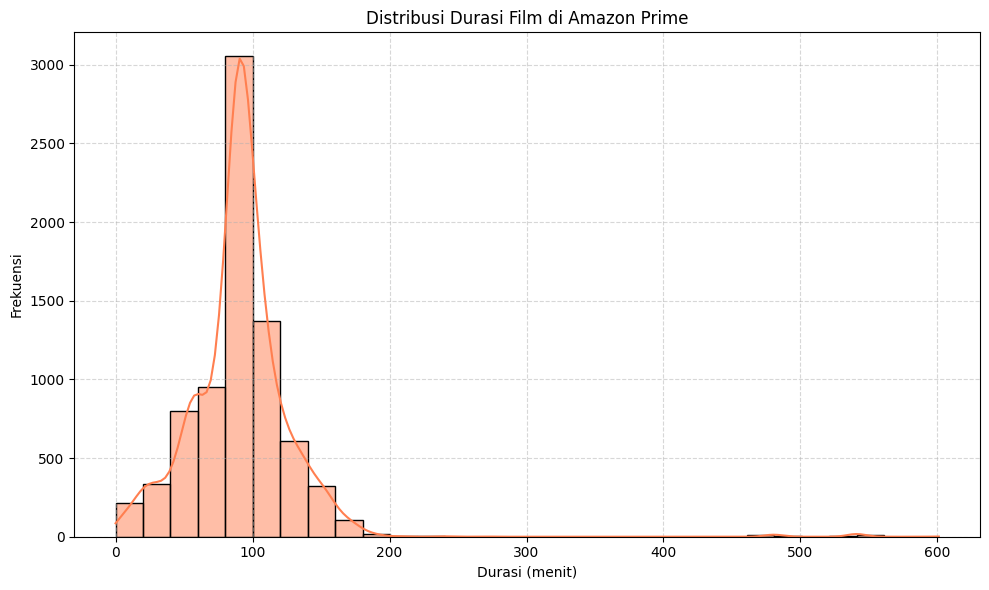

In [10]:
# Filter hanya Movie
movies = df[df['type'] == 'Movie'].copy()

# Ambil hanya nilai durasi yang berformat menit (mengandung 'min')
movies = movies[movies['duration'].str.contains('min', na=False)]

# Hapus 'min' dan ubah ke numerik
movies['duration'] = movies['duration'].str.replace(' min', '', regex=False)
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

# Plot distribusi
plt.figure(figsize=(10, 6))
sns.histplot(movies['duration'].dropna(), bins=30, kde=True, color='coral')
plt.title('Distribusi Durasi Film di Amazon Prime')
plt.xlabel('Durasi (menit)')
plt.ylabel('Frekuensi')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


###**5. Distribusi Durasi TV Series**

Visualisasi menunjukkan distribusi jumlah season pada TV Show di Amazon Prime. Mayoritas serial memiliki hanya 1 season, menunjukkan dominasi format mini series atau limited series di platform ini.

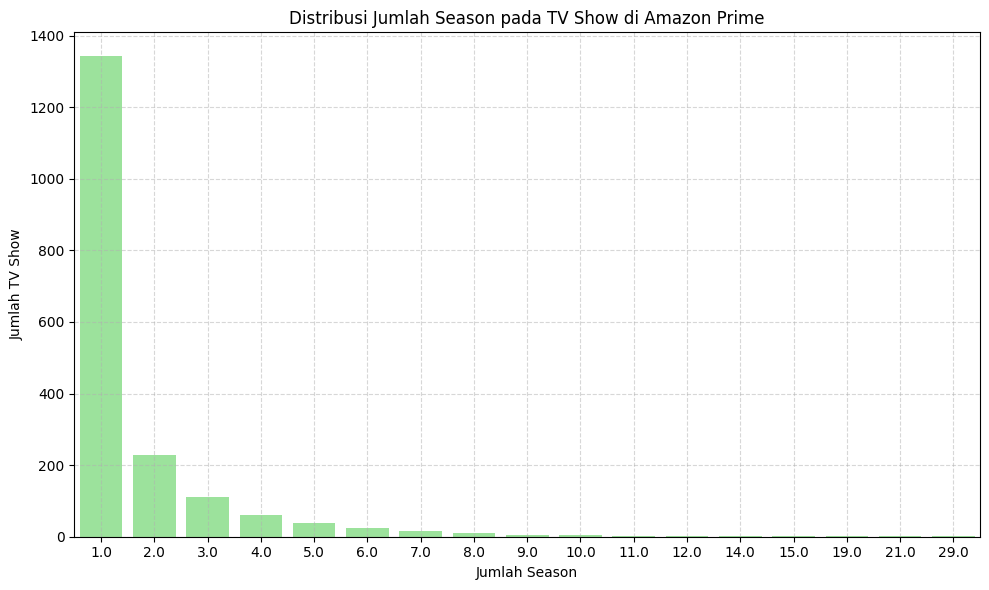

In [11]:
# Filter hanya TV Show
tv_shows = df[df['type'] == 'TV Show'].copy()

# Ambil angka dari durasi (misalnya '2 Seasons' → 2)
tv_shows['seasons'] = tv_shows['duration'].str.extract('(\d+)').astype(float)

# Visualisasi distribusi jumlah season
plt.figure(figsize=(10, 6))
sns.countplot(x='seasons', data=tv_shows, color='lightgreen')
plt.title('Distribusi Jumlah Season pada TV Show di Amazon Prime')
plt.xlabel('Jumlah Season')
plt.ylabel('Jumlah TV Show')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## **Data Preparation**

###**1. Handling Missing Values**

Nilai yang hilang pada kolom director dan cast akan diimputant dengan data "unknown" sedangkan kolom rating akan diisi dengan modus.

In [12]:
# Imputant missing values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

Menghapus kolom date_added dan country dikarenakan nilai yang hilang terlalu banyak

In [13]:
# remove country and date_added
df = df.drop(['country','date_added'], axis=1)

Cek kembali Missing Value setelah dilakukan Handling

In [14]:
# Cek missing values
missing_values = df.isnull().sum()
print(missing_values)

show_id           0
type              0
title             0
director          0
cast              0
release_year      0
rating            0
duration          0
listed_in         0
description       0
year_group      353
dtype: int64


### **2. Replace Rating**

Dalam dataset, ada beberapa nilai yang sebenarnya sama, tetapi ditulis dengan nama atau format yang berbeda. Untuk membuat data lebih konsisten dan mudah dianalisis, nama-nama tersebut diganti atau diseragamkan menjadi satu format yang sama.

In [15]:
#basically we are replacing the names to make it less cluster
df['rating']=df['rating'].replace({
    "16": "16+",
    "AGES_16_": "16+",
    "AGES_18_": "18+",
    "R": "18+",
    "NC-17": "18+",
    "13+": "PG-13",
    "PG-13": "PG-13",
    "G": "GENERAL",
    "ALL": "GENERAL",
    "ALL_AGES": "GENERAL",
    "UNRATED": "UNRATED",
    "NOT_RATE": "UNRATED",
    "NR": "UNRATED",
    "7+": "TV-Y7",
    "TV-NR": "TV-UNRATED"
})

### **3. Mengkategorikan Duration**

Memisahkan antara waktu movie dengan season

In [16]:
df['duration_by_min']=df['duration'].str.split('min',expand=True)[0]
df.head()

,show_id,type,title,director,cast,release_year,rating,duration,listed_in,description,year_group,duration_by_min
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",2014,PG-13,113 min,"Comedy, Drama",A small fishing village must procure a local d...,2010-14,113
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",2018,PG-13,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...,2015-19,110
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",2017,PG-13,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...,2015-19,74
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",2014,PG-13,69 min,Documentary,"Pink breaks the mold once again, bringing her ...",2010-14,69
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",1989,PG-13,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...,1980s,45


Mendefinisikan duration by min

In [17]:
def condi(x):
    if 'min' in x:
        return int(x.split()[0])
    else:
        return 0
df['duration_in_min']=df['duration'].apply(condi)

df.head()

,show_id,type,title,director,cast,release_year,rating,duration,listed_in,description,year_group,duration_by_min,duration_in_min
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",2014,PG-13,113 min,"Comedy, Drama",A small fishing village must procure a local d...,2010-14,113,113
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",2018,PG-13,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...,2015-19,110,110
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",2017,PG-13,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...,2015-19,74,74
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",2014,PG-13,69 min,Documentary,"Pink breaks the mold once again, bringing her ...",2010-14,69,69
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",1989,PG-13,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...,1980s,45,45


Mendefinisikan duration by season

In [18]:
def condi(x):
    if 'season' in x:
        return int(x.split()[0])
    else:
        return 0
df['duration_in_seasons']=df['duration'].apply(condi)

df.head()

,show_id,type,title,director,cast,release_year,rating,duration,listed_in,description,year_group,duration_by_min,duration_in_min,duration_in_seasons
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",2014,PG-13,113 min,"Comedy, Drama",A small fishing village must procure a local d...,2010-14,113,113,0
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",2018,PG-13,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...,2015-19,110,110,0
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",2017,PG-13,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...,2015-19,74,74,0
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",2014,PG-13,69 min,Documentary,"Pink breaks the mold once again, bringing her ...",2010-14,69,69,0
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",1989,PG-13,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...,1980s,45,45,0


In [19]:
df['show_id'] = df['show_id'].str.replace('s', '')

In [20]:
df['duration_in_min'] = df['duration_in_min'].astype(int)
df['duration_in_seasons'] = df['duration_in_seasons'].astype(int)
df['show_id'] = df['show_id'].astype(int)

Hapus apabila tidak diperlukan

In [21]:
df=df.drop(columns=['duration'], axis=1)

In [22]:
df_clean=df.copy()

##**Modelling**

###**1. Model Development Content Based Filtering**

Digunakan untuk merekomendasikan film atau TV show berdasarkan kemiripan konten seperti genre, deskripsi, sutradara, dll.

In [23]:
df_CBF=df_clean.copy()

In [24]:
# Ambil kolom yang relevan
df_CBF['combined_features'] = df_CBF['title'].fillna('') + ' ' + \
                          df_CBF['director'].fillna('') + ' ' + \
                          df_CBF['cast'].fillna('') + ' ' + \
                          df_CBF['listed_in'].fillna('') + ' ' + \
                          df_CBF['description'].fillna('')

# Ubah ke dalam bentuk vektor TF-IDF
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_CBF['combined_features'])

# Cek hasil vektorisasi
print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")

TF-IDF Matrix Shape: (9668, 52408)


In [25]:
# Konversi TF-IDF matrix ke bentuk dense dan buat DataFrame
tfidf_df = pd.DataFrame(
    tfidf_matrix.todense(),
    columns=tfidf.get_feature_names_out(),
    index=df_CBF['title']
)

# Tampilkan 5 baris pertama
print(tfidf_df.head())

                       00  000  007   01   02   03   05   09   10  100  ...  \
title                                                                   ...   
The Grand Seduction   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
Take Care Good Night  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
Secrets of Deception  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
Pink: Staying True    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
Monster Maker         0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   

                      篠崎雅美  美村多栄  藤村明世  辰寿広美  辻凪子  辻葉子  齋藤雅弘  ﬁgure  ﬁrst  ｇｅｔ  
title                                                                           
The Grand Seduction    0.0   0.0   0.0   0.0  0.0  0.0   0.0    0.0   0.0  0.0  
Take Care Good Night   0.0   0.0   0.0   0.0  0.0  0.0   0.0    0.0   0.0  0.0  
Secrets of Deception   0.0   0.0   0.0   0.0  0.0  0.0   0.0    0.0   0.0  0.0  
Pink: Staying True     0.0   0.0   0.0   

In [26]:
# Hitung kemiripan antar konten
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Buat mapping antara judul dan index DataFrame
indices = pd.Series(df.index, index=df_CBF['title'].str.lower()).drop_duplicates()

Matriks Kemiripan Antar Judul

In [27]:
cosine_sim_df = pd.DataFrame(cosine_sim,
                             index=df_CBF['title'],
                             columns=df_CBF['title'])
print(f"Cosine Similarity Matrix Shape: {cosine_sim_df.shape}")

Cosine Similarity Matrix Shape: (9668, 9668)


In [28]:
print("Sample Cosine Similarity Matrix:")
print(cosine_sim_df.sample(5, axis=1, random_state=42).sample(10, axis=0, random_state=42)
)

Sample Cosine Similarity Matrix:
title                         Arpo: The Robot for All Kids  \
title                                                        
Arpo: The Robot for All Kids                      1.000000   
Gangstars (Telugu)                                0.004986   
Sankarabharanam                                   0.000000   
Gulabo Sitabo (4K UHD)                            0.000000   
The Evening Star                                  0.000000   
Last Call For Titan!                              0.008453   
Defendor                                          0.000000   
Memories of Nanette                               0.033081   
Tugged                                            0.005541   
Josh Blue: Delete                                 0.000000   

title                         Gangstars (Telugu)  Sankarabharanam  \
title                                                               
Arpo: The Robot for All Kids            0.004986         0.000000   
Gangstars (Telu

#### **Sistem Rekomendasi**

In [29]:
# Hitung cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Membuat fungsi rekomendasi berbasis konten
def get_recommendations(title, df_CBF, cosine_sim_matrix, top_n=10):
    title = title.strip()

    # Cek apakah judul ada di DataFrame
    if title not in df_CBF['title'].values:
        return f"[ERROR] Judul '{title}' tidak ditemukan dalam dataset."

    # Temukan indeks berdasarkan judul
    idx = df_CBF[df_CBF['title'] == title].index[0]

    # Ambil skor similarity untuk semua item
    sim_scores = list(enumerate(cosine_sim_matrix[idx]))

    # Urutkan berdasarkan similarity tertinggi
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Ambil top_n hasil teratas, selain dirinya sendiri (index 0)
    top_indices = [i[0] for i in sim_scores[1:top_n+1]]

    # Ambil judul film/TV show sebagai hasil
    recommended = df_CBF[['title', 'type', 'listed_in']].iloc[top_indices]
    recommended['similarity_score'] = [sim_scores[i+1][1] for i in range(top_n)]

    return recommended.reset_index(drop=True)

# Contoh penggunaan
recommendations = get_recommendations("Halloween Heroes", df_CBF, cosine_sim)
print(recommendations)

                                               title     type  \
0                          CoComelon Halloween Songs    Movie   
1  Morphle Halloween Special - The Halloween Cand...    Movie   
2  Rhymes for Kids and Babies - Spooky Halloween ...    Movie   
3  Steve and Maggie - Haunted Halloween Special (...    Movie   
4                        Oddbods - Halloween Special    Movie   
5                   Blippi's Spooky Spells Halloween    Movie   
6             Pinkfong! Baby Shark & Halloween Songs  TV Show   
7                    Bobby Slayton: Born To Be Bobby    Movie   
8    The Cat in the Hat Knows a Lot About Halloween!    Movie   
9            Halloween Kids Songs by Little Baby Bum    Movie   

                                           listed_in  similarity_score  
0                                               Kids          0.203386  
1                                    Animation, Kids          0.189124  
2                                               Kids          0.1

####**Evaluasi Model Development Content Based Filtering**

In [30]:
relevant_movies = [
    'Faster',
    'Halloween Kids Songs by Little Baby Bum',
    'Halloween Heroes',
    '27 September'
]

In [31]:
def precision_at_k(recommended, relevant, k):
    if not recommended or k == 0:
        return 0.0
    recommended_at_k = set(recommended[:k])
    relevant_set = set(relevant)
    precision = len(recommended_at_k & relevant_set) / k
    return round(precision, 4)

def recall_at_k(recommended, relevant, k):
    if not relevant:
        return 0.0
    recommended_at_k = set(recommended[:k])
    relevant_set = set(relevant)
    recall = len(recommended_at_k & relevant_set) / len(relevant_set)
    return round(recall, 4)

def f1_score_at_k(recommended, relevant, k):
    precision = precision_at_k(recommended, relevant, k)
    recall = recall_at_k(recommended, relevant, k)
    if precision + recall == 0:
        return 0.0
    f1 = 2 * (precision * recall) / (precision + recall)
    return round(f1, 4)

In [32]:
def evaluate_recommendation_system(query_title, ground_truth, k=10):
    try:
        recommendations = get_recommendations(query_title, df_clean, cosine_sim)

        # Extract list of recommended titles
        recommended_titles = recommendations['title'].tolist()

        precision = precision_at_k(recommended_titles, ground_truth, k)
        recall = recall_at_k(recommended_titles, ground_truth, k)
        f1 = f1_score_at_k(recommended_titles, ground_truth, k)

        print(f"\nEvaluation for: '{query_title}'")
        print(f"Top-{k} Recommendations: {recommended_titles[:k]}")
        print(f"Ground Truth: {ground_truth}")
        print(f"\nPrecision@{k}: {precision}")
        print(f"Recall@{k}:    {recall}")
        print(f"F1-Score@{k}:  {f1}")

        return {
            "precision": precision,
            "recall": recall,
            "f1_score": f1
        }

    except Exception as e:
        print(f"[ERROR] Gagal mengevaluasi: {e}")
        return None


evaluate_recommendation_system("The Cat in the Hat Knows a Lot About Halloween!", relevant_movies, k=10)


Evaluation for: 'The Cat in the Hat Knows a Lot About Halloween!'
Top-10 Recommendations: ['The Cat in the Hat Knows a Lot About Christmas', 'The Cat in the Hat Knows a Lot About Camping!', 'The Cat in the Hat Knows a Lot About Space!', 'The Cat in the Hat Knows a Lot About That!', 'Morphle Halloween Special - The Halloween Candy Magic Pet', 'CoComelon Halloween Songs', 'Oddbods - Halloween Special', 'Steve and Maggie - Haunted Halloween Special (Vol. 4)', 'Rhymes for Kids and Babies - Spooky Halloween Songs - Mother Goose Club', 'Halloween Kids Songs by Little Baby Bum']
Ground Truth: ['Faster', 'Halloween Kids Songs by Little Baby Bum', 'Halloween Heroes', '27 September']

Precision@10: 0.1
Recall@10:    0.25
F1-Score@10:  0.1429


{'precision': 0.1, 'recall': 0.25, 'f1_score': 0.1429}

###**2. Model Development Collaborative Filtering**

In [33]:
df_CF=df_clean.copy()

In [34]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

df_CF['userId'] = np.random.randint(1, 1001, df_CF.shape[0])
df_CF['movseri_id'] = df_CF['show_id'].astype('category').cat.codes

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply Label Encoding to the 'Color' column
df_CF['rating'] = label_encoder.fit_transform(df_CF['rating'])

df_collab = df_CF[['userId', 'movseri_id', 'rating']]

# Cek data
df_collab.head()

,userId,movseri_id,rating
0,663,0,4
1,566,1,4
2,327,2,4
3,866,3,4
4,520,4,4


In [35]:
train_data, test_data = train_test_split(df_collab, test_size=0.3, random_state=42)

from sklearn.model_selection import train_test_split

# Bagi data
train_data, test_data = train_test_split(df_collab, test_size=0.2, random_state=42)

# Ambil input dan konversi ke int32
train_user_input = train_data['userId'].values.astype(np.int32)
train_item_input = train_data['movseri_id'].values.astype(np.int32)
train_ratings = train_data['rating'].values.astype(np.float32)

test_user_input = test_data['userId'].values.astype(np.int32)
test_item_input = test_data['movseri_id'].values.astype(np.int32)
test_ratings = test_data['rating'].values.astype(np.float32)


#### **Neural Collaborative Filtering (NCF)**

In [36]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate
from tensorflow.keras.optimizers import Adam
import numpy as np
import tensorflow as tf # Import tensorflow
from tensorflow.keras.metrics import MeanSquaredError
import tensorflow.keras.backend as K # Import Keras backend as K


# Parameter
num_users = df_collab['userId'].nunique()
num_items = df_collab['movseri_id'].nunique()
embedding_dim = 50

train_user_input = np.clip(train_user_input, 0, num_users - 1)
train_item_input = np.clip(train_item_input, 0, num_items - 1)

# Cek dimensi dan validasi
assert train_user_input.min() >= 0 and train_user_input.max() <= num_users - 1, "User ID tidak valid!"
assert train_item_input.min() >= 0 and train_item_input.max() <= num_items - 1, "Movie ID tidak valid!"
train_user_input = train_user_input.flatten()
train_item_input = train_item_input.flatten()

# Model NCF

# Input layer
user_input = Input(shape=(1,))
item_input = Input(shape=(1,))

# Embedding layer
user_embed = Embedding(input_dim=num_users, output_dim=embedding_dim)(user_input)
item_embed = Embedding(input_dim=num_items, output_dim=embedding_dim)(item_input)

# Flatten layer
user_vec = Flatten()(user_embed)
item_vec = Flatten()(item_embed)

# Concatenate user and item vectors
merged = Concatenate()([user_vec, item_vec])

# Dense layers
x = Dense(64, activation='relu')(merged)
output = Dense(1)(x)

# Fungsi untuk menghitung RMSE
def rmse(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_pred - y_true))) # Now K is defined

# Membuat dan kompilasi model
model = Model(inputs=[user_input, item_input], outputs=output)

# Compile model dengan MSE dan RMSE sebagai metrik
model.compile(optimizer=Adam(),
              loss='mean_squared_error',
              metrics=[MeanSquaredError(),
                       rmse])

# Menampilkan summary model
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 50)     │     50,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 50)     │    483,400 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 50)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100)       │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      6,464 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 539,929 (2.06 MB)

 Trainable params: 539,929 (2.06 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Pastikan train_ratings memiliki tipe data yang sesuai
train_ratings = train_ratings.astype(np.float32)

# Melatih model
history = model.fit(
    [train_user_input, train_item_input],  # dua input
    train_ratings,  # target ratings
    epochs=40,
    batch_size=64
)

Epoch 1/40
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 17.1273 - mean_squared_error: 17.1273 - rmse: 4.1132
Epoch 2/40
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 9.1651 - mean_squared_error: 9.1651 - rmse: 3.1576
Epoch 3/40
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.6888 - mean_squared_error: 4.6888 - rmse: 3.4420
Epoch 4/40
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.4098 - mean_squared_error: 1.4098 - rmse: 4.1124
Epoch 5/40
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8996 - mean_squared_error: 0.8996 - rmse: 4.1813
Epoch 6/40
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5388 - mean_squared_error: 0.5388 - rmse: 4.2419
Epoch 7/40
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.3082 - mean_squared_error: 0.3082 - rmse: 4.2811
Epoch 8/40
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2058 - mean_squared_error: 0.2058 - rmse: 4.3215
Epoch 9/40
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1536 - mean_squared_error: 0.1536 - rmse: 4.230

In [38]:
import numpy as np

# Fungsi untuk mendapatkan rekomendasi film berdasarkan prediksi rating
def get_movie_recommendations(user_id, num_recommendations=10):
    # Semua ID film yang tersedia
    movseri_ids = np.arange(num_items)

    # Membuat array user_id dengan panjang sama
    user_ids = np.full_like(movseri_ids, user_id)

    # Prediksi rating untuk semua (user_id, movie_id)
    predictions = model.predict([user_ids, movseri_ids], verbose=0).flatten()

    # Ambil ID film dengan rating tertinggi
    top_indices = predictions.argsort()[::-1][:num_recommendations]
    recommended_ids = movseri_ids[top_indices]

    # Ambil data film dari df_CF (berdasarkan movseri_id)
    recommended_movies = df_CF[df_CF['movseri_id'].isin(recommended_ids)][['title', 'listed_in']].drop_duplicates()

    return recommended_movies.reset_index(drop=True)


In [39]:
# Contoh: Mendapatkan 10 rekomendasi film untuk user tertentu
user_id = 70  # Ganti dengan ID user yang ingin diuji

# Ambil rekomendasi dari fungsi
recommended_movies = get_movie_recommendations(user_id, num_recommendations=10)

# Tampilkan hasil rekomendasi
print(f"Top 10 rekomendasi film untuk user {user_id}:\n")
for i, row in recommended_movies.iterrows():
    print(f"{i+1}. Title: {row['title']}  |  Genre: {row['listed_in']}")

Top 10 rekomendasi film untuk user 70:

1. Title: Ujda Chaman (4K UHD)  |  Genre: Comedy, International
2. Title: Thrissur Pooram (4K UHD)  |  Genre: Action
3. Title: The PRiMMS  |  Genre: Music Videos and Concerts
4. Title: The Dying of the Light  |  Genre: Documentary
5. Title: Oxford Collapse  |  Genre: Music Videos and Concerts
6. Title: Made in Mexico (Spanish Language, No Subtitles)  |  Genre: Music Videos and Concerts
7. Title: Jill Cunniff  |  Genre: Special Interest
8. Title: Gil Mantera's Party Dream  |  Genre: Music Videos and Concerts
9. Title: Au Revoir Simone  |  Genre: Music Videos and Concerts
10. Title: Caught  |  Genre: Suspense


####**Evaluasi Collaborative Filtering**

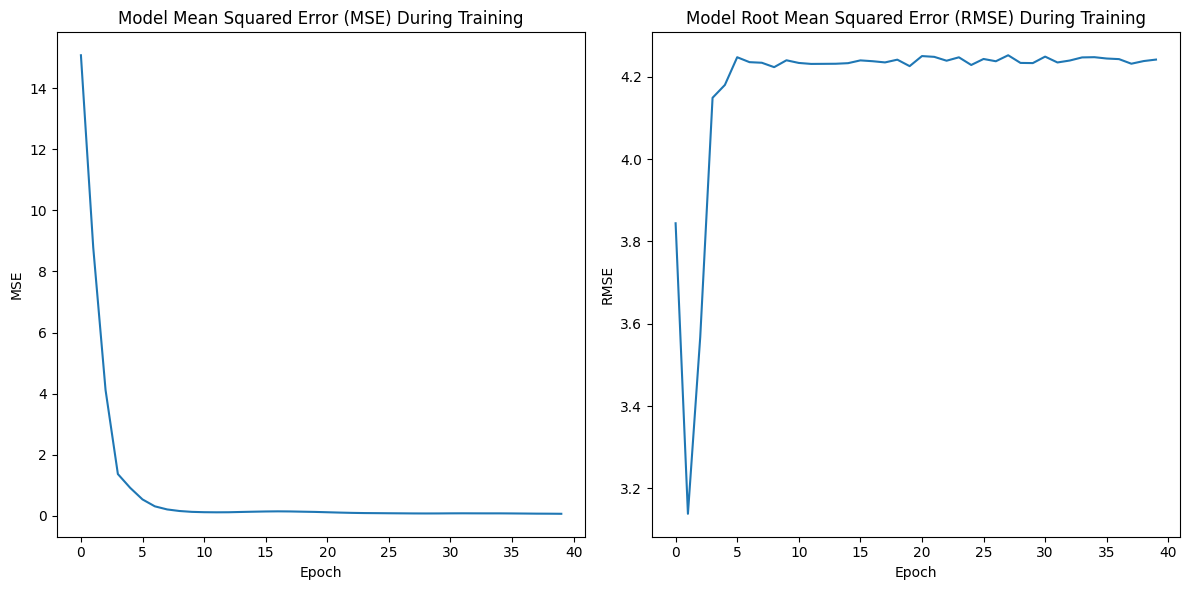

In [40]:
import matplotlib.pyplot as plt

# Mengambil data MSE dan RMSE dari history
mse = history.history['mean_squared_error']
rmse = history.history['rmse']

# Membuat plot MSE selama training
plt.figure(figsize=(12, 6))

# Plot MSE
plt.subplot(1, 2, 1)
plt.plot(mse)
plt.title('Model Mean Squared Error (MSE) During Training')
plt.xlabel('Epoch')
plt.ylabel('MSE')

# Plot RMSE
plt.subplot(1, 2, 2)
plt.plot(rmse)
plt.title('Model Root Mean Squared Error (RMSE) During Training')
plt.xlabel('Epoch')
plt.ylabel('RMSE')

plt.tight_layout()
plt.show()